# Sentiment Detection using TextBlob

## Objective
To detect the emotional tone of text data by measuring **polarity** and **subjectivity** using the TextBlob library.  
This method is **lexicon-based**, meaning it relies on predefined dictionaries of positive and negative words.

---

## What is Sentiment Analysis?
Sentiment analysis identifies the emotional intent of a text — whether it is **positive**, **negative**, or **neutral**.

### Polarity
Polarity measures **how positive or negative** a piece of text is.  
It ranges from **-1 (very negative)** to **+1 (very positive)**.  
A value near 0 represents **neutral** sentiment.

### Subjectivity
Subjectivity measures **how opinionated or factual** a text is.  
It ranges from **0 (completely objective)** to **1 (highly subjective)**.  
For example,  
- “The phone is expensive” → subjective opinion  
- “The phone has a 6-inch screen” → objective statement

---

## Steps to Perform Sentiment Analysis
1. Import the required libraries.  
2. Load or create sample text data.  
3. Use TextBlob to compute polarity and subjectivity.  
4. Assign sentiment labels as Positive, Negative, or Neutral.  
5. Plot a bar chart showing the count of each sentiment.  
6. Generate small word clouds for each sentiment category.

---

## Expected Output
- Each text row will have corresponding **polarity**, **subjectivity**, and **sentiment label**.  
- A **barplot** will display sentiment counts.  
- **Word clouds** will show frequently used words within each sentiment group.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arather\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arather\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
#  Sample Text Dataset
data = {
    'text': [
        'I love this phone, it works great!',
        'The product quality is terrible.',
        'Battery life is okay, not too bad.',
        'Absolutely fantastic movie!',
        'Worst customer service experience.',
        'The taste of the food was amazing!',
        'Not sure if I like this design.',
        'Horrible, waste of money.',
        'Excellent support and fast delivery.',
        'Mediocre performance, expected better.'
    ]
}
df = pd.DataFrame(data)

print (df.head())

                                 text
0  I love this phone, it works great!
1    The product quality is terrible.
2  Battery life is okay, not too bad.
3         Absolutely fantastic movie!
4  Worst customer service experience.


In [3]:
# Compute Polarity and Subjectivity
df['polarity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

print(df)

                                     text  polarity  subjectivity
0      I love this phone, it works great!  0.750000      0.675000
1        The product quality is terrible. -1.000000      1.000000
2      Battery life is okay, not too bad. -0.100000      0.583333
3             Absolutely fantastic movie!  0.500000      0.900000
4      Worst customer service experience. -1.000000      1.000000
5      The taste of the food was amazing!  0.750000      0.900000
6         Not sure if I like this design. -0.250000      0.888889
7               Horrible, waste of money. -0.600000      0.500000
8    Excellent support and fast delivery.  0.600000      0.800000
9  Mediocre performance, expected better. -0.033333      0.633333


In [4]:
#  Assign Sentiment Labels
def get_sentiment_label(score):
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['polarity'].apply(get_sentiment_label)

print(df)

                                     text  polarity  subjectivity sentiment
0      I love this phone, it works great!  0.750000      0.675000  positive
1        The product quality is terrible. -1.000000      1.000000  negative
2      Battery life is okay, not too bad. -0.100000      0.583333   neutral
3             Absolutely fantastic movie!  0.500000      0.900000  positive
4      Worst customer service experience. -1.000000      1.000000  negative
5      The taste of the food was amazing!  0.750000      0.900000  positive
6         Not sure if I like this design. -0.250000      0.888889  negative
7               Horrible, waste of money. -0.600000      0.500000  negative
8    Excellent support and fast delivery.  0.600000      0.800000  positive
9  Mediocre performance, expected better. -0.033333      0.633333   neutral


In [5]:
#  Clean Text for WordCloud
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_text)
print(df)

                                     text  polarity  subjectivity sentiment  \
0      I love this phone, it works great!  0.750000      0.675000  positive   
1        The product quality is terrible. -1.000000      1.000000  negative   
2      Battery life is okay, not too bad. -0.100000      0.583333   neutral   
3             Absolutely fantastic movie!  0.500000      0.900000  positive   
4      Worst customer service experience. -1.000000      1.000000  negative   
5      The taste of the food was amazing!  0.750000      0.900000  positive   
6         Not sure if I like this design. -0.250000      0.888889  negative   
7               Horrible, waste of money. -0.600000      0.500000  negative   
8    Excellent support and fast delivery.  0.600000      0.800000  positive   
9  Mediocre performance, expected better. -0.033333      0.633333   neutral   

                           cleaned_text  
0                 love phone work great  
1              product quality terrible  
2   

In [6]:
# Step 7: Display Resulting Data
print(df[['text', 'polarity', 'subjectivity', 'sentiment']])

                                     text  polarity  subjectivity sentiment
0      I love this phone, it works great!  0.750000      0.675000  positive
1        The product quality is terrible. -1.000000      1.000000  negative
2      Battery life is okay, not too bad. -0.100000      0.583333   neutral
3             Absolutely fantastic movie!  0.500000      0.900000  positive
4      Worst customer service experience. -1.000000      1.000000  negative
5      The taste of the food was amazing!  0.750000      0.900000  positive
6         Not sure if I like this design. -0.250000      0.888889  negative
7               Horrible, waste of money. -0.600000      0.500000  negative
8    Excellent support and fast delivery.  0.600000      0.800000  positive
9  Mediocre performance, expected better. -0.033333      0.633333   neutral


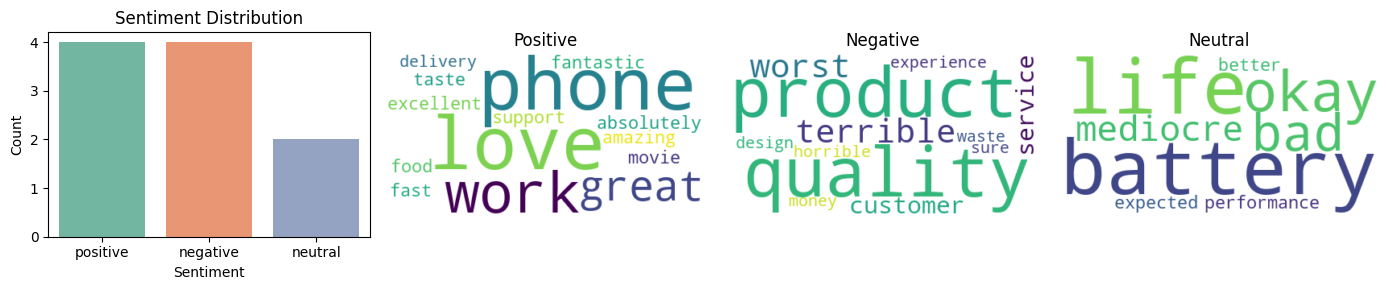

In [7]:
#  Visualization — Barplot + WordClouds
sentiments = df['sentiment'].unique()
fig, axes = plt.subplots(1, len(sentiments) + 1, figsize=(14, 3))

# Barplot
sns.countplot(x='sentiment', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# WordClouds for each sentiment
for i, sentiment in enumerate(sentiments):
    text = ' '.join(df[df['sentiment'] == sentiment]['cleaned_text'])
    wordcloud = WordCloud(width=400, height=200, background_color='white').generate(text)
    axes[i+1].imshow(wordcloud, interpolation='bilinear')
    axes[i+1].axis('off')
    axes[i+1].set_title(f'{sentiment.capitalize()}')

plt.tight_layout()
plt.show()




# Understanding Core NLP Steps in Sentiment Analysis

## Does the Previous Notebook Follow All Core Steps?

The sentiment analysis notebook used **TextBlob**, a lexicon-based approach that directly computes  
**polarity** and **subjectivity** from text. It does not explicitly show **tokenization, stopword removal, or lemmatization**,  
because these steps are internally managed by TextBlob during sentiment computation.

This approach is correct for demonstrating *how polarity and subjectivity are derived* automatically,  
but it skips the detailed preprocessing workflow used in traditional NLP pipelines.

---

## Core NLP Steps for Sentiment Analysis

To understand the complete process, sentiment analysis can be divided into the following stages:

| Stage | Step | Description |
|-------|------|-------------|
| **1** | **Text Cleaning** | Remove punctuation, numbers, and special symbols. |
| **2** | **Tokenization** | Split the text into individual words or tokens. |
| **3** | **Stopword Removal** | Remove common words like *the, is, and, a* that carry little meaning. |
| **4** | **Lemmatization / Stemming** | Reduce words to their root form (e.g., *running → run*). |
| **5** | **Feature Representation** | Convert text into numeric form using Bag of Words, TF–IDF, or embeddings. |
| **6** | **Sentiment Detection** | Compute polarity (lexicon-based) or train models (machine learning based). |
| **7** | **Visualization** | Plot sentiment counts, polarity distributions, or generate word clouds. |

---

## What the Current Notebook Does
The current notebook focuses on:
- **Lexicon-based Sentiment Detection** using TextBlob  
- **Polarity and Subjectivity Computation**  
- **Visualization** through bar plots and word clouds  

It demonstrates sentiment detection efficiently without showing the preprocessing steps in depth.

---

## What Should Follow Next
The next notebook will demonstrate:
- Text cleaning  
- Tokenization  
- Stopword removal  
- Lemmatization  

These are essential preprocessing steps before applying any sentiment analysis or classification technique.
